# Прогнозирование цен на недвижимость с помощью линейной регрессии


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})


def find_project_dir() -> Path:
    current_dir = Path.cwd().resolve()
    candidates = [
        current_dir,
        current_dir.parent,
        current_dir / "1_linear_regression_house_prices",
        current_dir.parent / "1_linear_regression_house_prices",
    ]

    for candidate in candidates:
        if (candidate / "data" / "prices_train.csv").exists():
            return candidate

    raise FileNotFoundError("Не удалось найти папку проекта с data/prices_train.csv")


BASE_DIR = find_project_dir()
DATA_DIR = BASE_DIR / "data"
SUBMISSIONS_DIR = BASE_DIR / "submissions"
SUBMISSIONS_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "prices_train.csv"
TEST_PATH = DATA_DIR / "prices_test.csv"

SUBMISSION_BASIC_PATH = SUBMISSIONS_DIR / "submission_00_basic.csv"
SUBMISSION_V1_PATH = SUBMISSIONS_DIR / "submission_01_added_features.csv"
SUBMISSION_NO_LOG_PATH = SUBMISSIONS_DIR / "submission_02_feature_sets_clipping.csv"
SUBMISSION_V2_PATH = SUBMISSIONS_DIR / "submission_03_with_log_target.csv"
FINAL_SUBMISSION_PATH = SUBMISSIONS_DIR / "submission.csv"

TARGET = "Y house price of unit area"

train = pd.read_csv(TRAIN_PATH, index_col=0)
test = pd.read_csv(TEST_PATH, index_col=0)
y_train = train[TARGET].copy()

def make_linear_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])


def evaluate_model(name, model, X, y, cv=5):
    fitted = clone(model)
    fitted.fit(X, y)
    train_pred = fitted.predict(X)
    train_mse = mean_squared_error(y, train_pred)

    oof_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=1)
    oof_mse = mean_squared_error(y, oof_pred)

    return {
        "model_step": name,
        "n_features": X.shape[1],
        "train_mse": train_mse,
        "train_rmse": np.sqrt(train_mse),
        "oof_mse": oof_mse,
        "oof_rmse": np.sqrt(oof_mse),
    }

BASE_DIR


## 1. Оценка качества моделей

Для сопоставления вариантов используется out-of-fold MSE, рассчитанная при пятикратной кросс-валидации. На каждой итерации модель обучается на четырех частях выборки и прогнозирует оставшуюся часть. После выбора лучшей конфигурации итоговая модель обучается на всей обучающей выборке и применяется к test.


In [2]:
def make_linear_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])


def evaluate_model(name, model, X, y, cv=5):
    fitted = clone(model)
    fitted.fit(X, y)
    train_pred = fitted.predict(X)
    train_mse = mean_squared_error(y, train_pred)

    oof_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=1)
    oof_mse = mean_squared_error(y, oof_pred)

    return {
        "model_step": name,
        "n_features": X.shape[1],
        "train_mse": train_mse,
        "train_rmse": np.sqrt(train_mse),
        "oof_mse": oof_mse,
        "oof_rmse": np.sqrt(oof_mse),
    }

## 2. Базовая модель

В качестве базовой модели используется линейная регрессия на признаках из исходных данных. Пропущенные значения заполняются медианой, признаки стандартизируются, после чего обучается модель `LinearRegression`.


In [ ]:
BASIC_FEATURES = [
    "X1 transaction date",
    "X2 house age",
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "X5 latitude",
    "X6 longitude",
]

basic_model = make_linear_pipeline()
basic_result = evaluate_model(
    "00_basic_raw_features",
    basic_model,
    train[BASIC_FEATURES],
    y_train,
)

basic_model.fit(train[BASIC_FEATURES], y_train)
basic_pred = basic_model.predict(test[BASIC_FEATURES])
basic_submission = pd.DataFrame({
    "index": test.index,
    TARGET: np.round(basic_pred, 2),
})
basic_submission.to_csv(SUBMISSION_BASIC_PATH, index=False)
print(f"Saved submission to: {SUBMISSION_BASIC_PATH}")

pd.DataFrame([basic_result]).round(4)

,model_step,n_features,train_mse,train_rmse,oof_mse,oof_rmse
0,00_basic_raw_features,6,77.8058,8.8208,79.9036,8.9389


### Вывод по базовой модели

Базовая модель использует только исходные признаки и служит контрольным уровнем качества. Значение OOF MSE показывает, что линейная зависимость по сырым признакам описывает данные неполно.


## 3. Сравнение линейной регрессии с регуляризацией и без

На исходных признаках сравниваются три варианта линейной модели:

- `LinearRegression` — модель без регуляризации
- `Ridge` — L2-регуляризация коэффициентов
- `Lasso` — L1-регуляризация коэффициентов

Для `Ridge` и `Lasso` подбирается значение `alpha` по OOF MSE. Предобработка и признаки остаются такими же, как в базовой модели.


In [4]:
def make_model_pipeline(estimator):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", estimator),
    ])


regularization_configs = [
    ("LinearRegression", np.nan, LinearRegression()),
    ("Ridge", 0.1, Ridge(alpha=0.1)),
    ("Ridge", 1.0, Ridge(alpha=1.0)),
    ("Ridge", 10.0, Ridge(alpha=10.0)),
    ("Ridge", 100.0, Ridge(alpha=100.0)),
    ("Lasso", 0.001, Lasso(alpha=0.001, max_iter=50000)),
    ("Lasso", 0.01, Lasso(alpha=0.01, max_iter=50000)),
    ("Lasso", 0.1, Lasso(alpha=0.1, max_iter=50000)),
    ("Lasso", 1.0, Lasso(alpha=1.0, max_iter=50000)),
]

regularization_rows = []

for model_type, alpha, estimator in regularization_configs:
    result = evaluate_model(
        model_type,
        make_model_pipeline(estimator),
        train[BASIC_FEATURES],
        y_train,
    )
    regularization_rows.append({
        "model_type": model_type,
        "alpha": alpha,
        "n_features": result["n_features"],
        "train_mse": result["train_mse"],
        "train_rmse": result["train_rmse"],
        "oof_mse": result["oof_mse"],
        "oof_rmse": result["oof_rmse"],
    })

regularization_results = pd.DataFrame(regularization_rows)
regularization_comparison = (
    regularization_results
    .sort_values("oof_mse")
    .groupby("model_type", as_index=False)
    .first()
)
regularization_comparison["model_type"] = pd.Categorical(
    regularization_comparison["model_type"],
    categories=["LinearRegression", "Ridge", "Lasso"],
    ordered=True,
)
regularization_comparison = regularization_comparison.sort_values("model_type").reset_index(drop=True)

display(regularization_comparison.round(4))


,model_type,alpha,n_features,train_mse,train_rmse,oof_mse,oof_rmse
0,LinearRegression,NaN,6,77.8058,8.8208,79.9036,8.9389
1,Ridge,1.00,6,77.8067,8.8208,79.8910,8.9382
2,Lasso,0.01,6,77.8061,8.8208,79.8924,8.9383


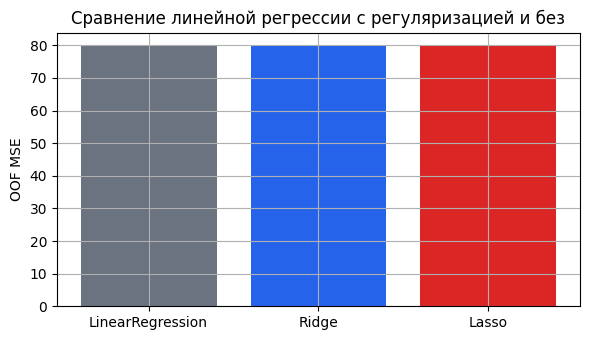

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(
    regularization_comparison["model_type"].astype(str),
    regularization_comparison["oof_mse"],
    color=["#6b7280", "#2563eb", "#dc2626"],
)
ax.set_title("Сравнение линейной регрессии с регуляризацией и без")
ax.set_ylabel("OOF MSE")
plt.tight_layout()
plt.show()


### Вывод по регуляризации

На исходных признаках регуляризация почти не изменила качество. Лучший результат показал `Ridge`: OOF MSE снизился с `79.9036` до `79.8910`. Улучшение несущественное, поэтому дальнейшее повышение качества связано не с регуляризацией, а с feature engineering и трансформацией целевой переменной.


## 4. Модель с добавлением признаков

Добавлены признаки, учитывающие нелинейные зависимости и взаимодействия между переменными:

- `log_dist` — логарифм расстояния до станции MRT;
- `age_sq` — квадрат возраста здания;
- `stores_x_logdist` — взаимодействие количества магазинов и расстояния;
- `geo_dist` — расстояние до условного географического центра.


In [6]:
def make_features_v1(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    d["log_dist"] = np.log1p(d["X3 distance to the nearest MRT station"])
    d["age_sq"] = d["X2 house age"] ** 2
    d["stores_x_logdist"] = d["X4 number of convenience stores"] * d["log_dist"]
    d["lat_center"] = d["X5 latitude"] - 24.97
    d["lon_center"] = d["X6 longitude"] - 121.50
    d["geo_dist"] = np.sqrt(d["lat_center"] ** 2 + d["lon_center"] ** 2)
    return d


FEATURES_V1 = [
    "X1 transaction date", "X2 house age",
    "log_dist", "X4 number of convenience stores",
    "X5 latitude", "X6 longitude",
    "age_sq", "stores_x_logdist", "geo_dist",
]

train_v1 = make_features_v1(train)
test_v1 = make_features_v1(test)

train_v1[FEATURES_V1].head().round(4)

,X1 transaction date,X2 house age,log_dist,X4 number of convenience stores,X5 latitude,X6 longitude,age_sq,stores_x_logdist,geo_dist
0,2013.083,34.0,5.0664,7.0,24.9663,121.5420,1156.00,35.4649,0.0421
1,2013.500,13.3,6.3333,5.0,24.9875,121.5439,176.89,31.6663,0.0473
2,2012.917,13.7,7.1209,1.0,24.9769,121.5539,187.69,7.1209,0.0544
3,2013.500,8.5,4.6616,5.0,24.9667,121.5407,72.25,23.3082,0.0408
4,2013.500,13.2,7.0612,NaN,24.9916,121.5341,174.24,NaN,0.0403


In [ ]:
model_v1 = make_linear_pipeline()
v1_result = evaluate_model(
    "01_added_features",
    model_v1,
    train_v1[FEATURES_V1],
    y_train,
)

model_v1.fit(train_v1[FEATURES_V1], y_train)
v1_pred = model_v1.predict(test_v1[FEATURES_V1])
v1_submission = pd.DataFrame({
    "index": test.index,
    TARGET: np.round(v1_pred, 2),
})
v1_submission.to_csv(SUBMISSION_V1_PATH, index=False)
print(f"Saved submission to: {SUBMISSION_V1_PATH}")

progress = pd.DataFrame([basic_result, v1_result])
progress.round(4)

,model_step,n_features,train_mse,train_rmse,oof_mse,oof_rmse
0,00_basic_raw_features,6,77.8058,8.8208,79.9036,8.9389
1,01_added_features,9,59.7710,7.7312,63.2545,7.9533


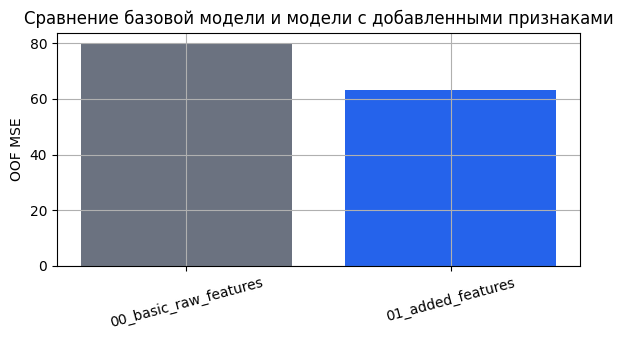

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(progress["model_step"], progress["oof_mse"], color=["#6b7280", "#2563eb"])
ax.set_title("Сравнение базовой модели и модели с добавленными признаками")
ax.set_ylabel("OOF MSE")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


### Вывод по добавлению признаков

Переход от исходных признаков к инженерным признакам снизил OOF MSE. Наиболее полезны признаки, отражающие расстояние до MRT, возраст здания и взаимодействие расстояния с числом магазинов.


## 5. Расширение признаков

Для финальной модели признаки расширены по нескольким группам:

- время сделки: `date_centered`, `date_sin`, `date_cos`;
- расстояние до MRT: `log_dist`, `inv_dist`;
- возраст здания: `age_sq`, `age_log`;
- координаты: `lat_c`, `lon_c`, `geo_dist`, `lat_sq`, `lon_sq`;
- взаимодействия: `lat_lon_interaction`, `stores_x_age`, `stores_x_lat`, `stores_x_lon`, `dist_x_age`.

Центры координат и даты рассчитываются по обучающей выборке.


In [9]:
lat0 = train["X5 latitude"].median()
lon0 = train["X6 longitude"].median()
date0 = train["X1 transaction date"].median()

print(f"lat0  = {lat0:.5f}")
print(f"lon0  = {lon0:.5f}")
print(f"date0 = {date0:.3f}")

lat0  = 24.97213
lon0  = 121.53913
date0 = 2013.083


In [10]:
def make_features_v2(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d = d.replace([np.inf, -np.inf], np.nan)

    date = d["X1 transaction date"]
    age = d["X2 house age"]
    dist = d["X3 distance to the nearest MRT station"]
    stores = d["X4 number of convenience stores"]
    lat = d["X5 latitude"]
    lon = d["X6 longitude"]

    d["date_centered"] = date - date0
    frac = date - np.floor(date)
    d["date_sin"] = np.sin(2 * np.pi * frac)
    d["date_cos"] = np.cos(2 * np.pi * frac)

    d["log_dist"] = np.log1p(dist)
    d["inv_dist"] = 1 / (1 + dist)

    d["age_sq"] = age ** 2
    d["age_log"] = np.log1p(age)

    d["lat_c"] = lat - lat0
    d["lon_c"] = lon - lon0
    d["geo_dist"] = np.sqrt(d["lat_c"] ** 2 + d["lon_c"] ** 2)
    d["lat_sq"] = d["lat_c"] ** 2
    d["lon_sq"] = d["lon_c"] ** 2
    d["lat_lon_interaction"] = d["lat_c"] * d["lon_c"]

    d["stores_x_logdist"] = stores * d["log_dist"]
    d["stores_x_age"] = stores * age
    d["stores_x_lat"] = stores * d["lat_c"]
    d["stores_x_lon"] = stores * d["lon_c"]
    d["dist_x_age"] = d["log_dist"] * age

    return d


train_v2 = make_features_v2(train)
test_v2 = make_features_v2(test)

new_v2_columns = [col for col in train_v2.columns if col not in train.columns]
train_v2[new_v2_columns].head().round(4)

,date_centered,date_sin,date_cos,log_dist,inv_dist,age_sq,age_log,lat_c,lon_c,geo_dist,lat_sq,lon_sq,lat_lon_interaction,stores_x_logdist,stores_x_age,stores_x_lat,stores_x_lon,dist_x_age
0,0.000,0.4982,0.8671,5.0664,0.0063,1156.00,3.5553,-0.0058,0.0028,0.0065,0.0000,0.0000,-0.0000,35.4649,238.0,-0.0409,0.0198,172.2582
1,0.417,0.0000,-1.0000,6.3333,0.0018,176.89,2.6603,0.0153,0.0048,0.0161,0.0002,0.0000,0.0001,31.6663,66.5,0.0766,0.0239,84.2323
2,-0.166,-0.4982,0.8671,7.1209,0.0008,187.69,2.6878,0.0048,0.0148,0.0155,0.0000,0.0002,0.0001,7.1209,13.7,0.0048,0.0148,97.5563
3,0.417,0.0000,-1.0000,4.6616,0.0095,72.25,2.2513,-0.0054,0.0015,0.0056,0.0000,0.0000,-0.0000,23.3082,42.5,-0.0269,0.0077,39.6240
4,0.417,0.0000,-1.0000,7.0612,0.0009,174.24,2.6532,0.0194,-0.0051,0.0201,0.0004,0.0000,-0.0001,NaN,NaN,NaN,NaN,93.2078


## 6. Наборы признаков

Для сравнения формируются три набора признаков: компактный, сбалансированный и расширенный географический. Это позволяет оценить, как количество признаков и доля координатных взаимодействий влияют на качество линейной модели.


In [11]:
FEATURE_SETS = {
    "balanced": [
        "X2 house age",
        "X4 number of convenience stores",
        "date_centered",
        "date_sin",
        "date_cos",
        "log_dist",
        "inv_dist",
        "age_sq",
        "lat_c",
        "lon_c",
        "geo_dist",
        "lat_lon_interaction",
        "stores_x_logdist",
        "stores_x_age",
    ],
    "geo_rich": [
        "X2 house age",
        "X4 number of convenience stores",
        "date_centered",
        "date_sin",
        "date_cos",
        "log_dist",
        "inv_dist",
        "age_sq",
        "age_log",
        "lat_c",
        "lon_c",
        "geo_dist",
        "lat_sq",
        "lon_sq",
        "lat_lon_interaction",
        "stores_x_logdist",
        "stores_x_age",
        "stores_x_lat",
        "stores_x_lon",
        "dist_x_age",
    ],
    "compact": [
        "X2 house age",
        "X4 number of convenience stores",
        "date_centered",
        "log_dist",
        "inv_dist",
        "age_sq",
        "lat_c",
        "lon_c",
        "geo_dist",
        "stores_x_logdist",
        "lat_lon_interaction",
    ],
}

pd.DataFrame({
    "feature_set": list(FEATURE_SETS),
    "n_features": [len(v) for v in FEATURE_SETS.values()],
})

,feature_set,n_features
0,balanced,14
1,geo_rich,20
2,compact,11


## 7. Обработка выбросов

Для снижения влияния крайних значений применяется clipping признаков по квантилям. Границы рассчитываются по обучающей выборке и затем применяются к train и test, чтобы сохранить одинаковую схему преобразования данных.


In [12]:
def clip_by_quantiles(train_df: pd.DataFrame, test_df: pd.DataFrame, cols, low_q: float, high_q: float):
    tr = train_df.copy()
    te = test_df.copy()

    for col in cols:
        lo = tr[col].quantile(low_q)
        hi = tr[col].quantile(high_q)
        tr[col] = tr[col].clip(lo, hi)
        te[col] = te[col].clip(lo, hi)

    return tr, te


clip_grid = [
    (0.005, 0.995),
    (0.01, 0.99),
    (0.02, 0.98),
    (0.03, 0.97),
]

clip_grid

[(0.005, 0.995), (0.01, 0.99), (0.02, 0.98), (0.03, 0.97)]

## 8. Модель с наборами признаков и clipping


In [ ]:
plain_rows = []

for feat_name, feats in FEATURE_SETS.items():
    for low_q, high_q in clip_grid:
        tr_clipped, _ = clip_by_quantiles(train_v2, test_v2, feats, low_q, high_q)
        X = tr_clipped[feats]

        model = make_linear_pipeline()
        oof_pred = cross_val_predict(model, X, y_train, cv=5, n_jobs=1)

        mse = mean_squared_error(y_train, oof_pred)
        plain_rows.append({
            "feature_set": feat_name,
            "low_q": low_q,
            "high_q": high_q,
            "n_features": len(feats),
            "oof_mse": mse,
            "oof_rmse": np.sqrt(mse),
        })

plain_search_results = pd.DataFrame(plain_rows).sort_values("oof_mse").reset_index(drop=True)
plain_best_row = plain_search_results.iloc[0]
plain_best_features = FEATURE_SETS[plain_best_row["feature_set"]]

X_train_plain, X_test_plain = clip_by_quantiles(
    train_v2,
    test_v2,
    plain_best_features,
    plain_best_row["low_q"],
    plain_best_row["high_q"],
)

plain_model = make_linear_pipeline()
plain_model.fit(X_train_plain[plain_best_features], y_train)
plain_train_pred = plain_model.predict(X_train_plain[plain_best_features])
plain_train_mse = mean_squared_error(y_train, plain_train_pred)
plain_train_rmse = np.sqrt(plain_train_mse)

plain_pred = plain_model.predict(X_test_plain[plain_best_features])

plain_submission = pd.DataFrame({
    "index": test.index,
    TARGET: np.round(plain_pred, 2),
})
plain_submission.to_csv(SUBMISSION_NO_LOG_PATH, index=False)
print(f"Saved submission to: {SUBMISSION_NO_LOG_PATH}")

plain_result = {
    "model_step": "02_feature_sets_clipping",
    "n_features": int(plain_best_row["n_features"]),
    "train_mse": plain_train_mse,
    "train_rmse": plain_train_rmse,
    "oof_mse": plain_best_row["oof_mse"],
    "oof_rmse": plain_best_row["oof_rmse"],
}

progress_with_clipping = pd.DataFrame([basic_result, v1_result, plain_result])

print("Best configuration for feature sets and clipping:")
print(f"feature_set = {plain_best_row['feature_set']}")
print(f"clipping    = ({plain_best_row['low_q']:.3f}, {plain_best_row['high_q']:.3f})")
print(f"OOF MSE     = {plain_best_row['oof_mse']:.4f}")
print(f"OOF RMSE    = {plain_best_row['oof_rmse']:.4f}")
print(f"n_features  = {len(plain_best_features)}")

display(plain_search_results.head(5).round(4))
display(progress_with_clipping.round(4))

Best configuration for feature sets and clipping:
feature_set = compact
clipping    = (0.030, 0.970)
OOF MSE     = 59.3076
OOF RMSE    = 7.7011
n_features  = 11


,feature_set,low_q,high_q,n_features,oof_mse,oof_rmse
0,compact,0.030,0.970,11,59.3076,7.7011
1,compact,0.020,0.980,11,59.4784,7.7122
2,geo_rich,0.010,0.990,20,59.9718,7.7441
3,compact,0.010,0.990,11,60.0907,7.7518
4,geo_rich,0.005,0.995,20,60.1309,7.7544


,model_step,n_features,train_mse,train_rmse,oof_mse,oof_rmse
0,00_basic_raw_features,6,77.8058,8.8208,79.9036,8.9389
1,01_added_features,9,59.7710,7.7312,63.2545,7.9533
2,02_feature_sets_clipping,11,55.9258,7.4784,59.3076,7.7011


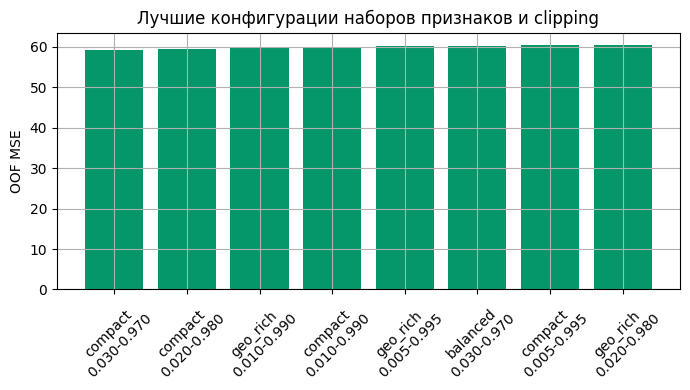

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_data = plain_search_results.head(8).copy()
plot_data["config"] = (
    plot_data["feature_set"]
    + "\n"
    + plot_data["low_q"].map(lambda x: f"{x:.3f}")
    + "-"
    + plot_data["high_q"].map(lambda x: f"{x:.3f}")
)
ax.bar(plot_data["config"], plot_data["oof_mse"], color="#059669")
ax.set_title("Лучшие конфигурации наборов признаков и clipping")
ax.set_ylabel("OOF MSE")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


### Вывод по наборам признаков и clipping

Компактный набор признаков с clipping оказался лучшей конфигурацией без лог-трансформации. Расширение набора признаков не дало дополнительного улучшения, поэтому часть координатных взаимодействий была избыточной.


## 9. Модель с лог-трансформацией

Целевая переменная преобразуется через `log1p(y)`, предсказания возвращаются в исходную шкалу через `expm1`.


In [15]:
def make_log_linear_model():
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


log_rows = []

for feat_name, feats in FEATURE_SETS.items():
    for low_q, high_q in clip_grid:
        tr_clipped, _ = clip_by_quantiles(train_v2, test_v2, feats, low_q, high_q)
        X = tr_clipped[feats]

        model = make_log_linear_model()
        oof_pred = cross_val_predict(model, X, y_train, cv=5, n_jobs=1)

        mse = mean_squared_error(y_train, oof_pred)
        log_rows.append({
            "feature_set": feat_name,
            "low_q": low_q,
            "high_q": high_q,
            "n_features": len(feats),
            "oof_mse": mse,
            "oof_rmse": np.sqrt(mse),
        })

log_search_results = pd.DataFrame(log_rows).sort_values("oof_mse").reset_index(drop=True)


In [16]:
best_row = log_search_results.iloc[0]
best_features = FEATURE_SETS[best_row["feature_set"]]

X_train_log, _ = clip_by_quantiles(
    train_v2,
    test_v2,
    best_features,
    best_row["low_q"],
    best_row["high_q"],
)

log_model_for_metrics = make_log_linear_model()
log_model_for_metrics.fit(X_train_log[best_features], y_train)
log_train_pred = log_model_for_metrics.predict(X_train_log[best_features])
log_train_mse = mean_squared_error(y_train, log_train_pred)
log_train_rmse = np.sqrt(log_train_mse)

log_result = {
    "model_step": "03_with_log_target",
    "n_features": int(best_row["n_features"]),
    "train_mse": log_train_mse,
    "train_rmse": log_train_rmse,
    "oof_mse": best_row["oof_mse"],
    "oof_rmse": best_row["oof_rmse"],
}

target_transform_comparison = pd.DataFrame([plain_result, log_result])

print("Best configuration:")
print(f"feature_set = {best_row['feature_set']}")
print(f"clipping    = ({best_row['low_q']:.3f}, {best_row['high_q']:.3f})")
print(f"OOF MSE     = {best_row['oof_mse']:.4f}")
print(f"OOF RMSE    = {best_row['oof_rmse']:.4f}")
print(f"n_features  = {len(best_features)}")

display(target_transform_comparison.round(4))

Best configuration:
feature_set = compact
clipping    = (0.030, 0.970)
OOF MSE     = 58.7477
OOF RMSE    = 7.6647
n_features  = 11


,model_step,n_features,train_mse,train_rmse,oof_mse,oof_rmse
0,02_feature_sets_clipping,11,55.9258,7.4784,59.3076,7.7011
1,03_with_log_target,11,56.1059,7.4904,58.7477,7.6647


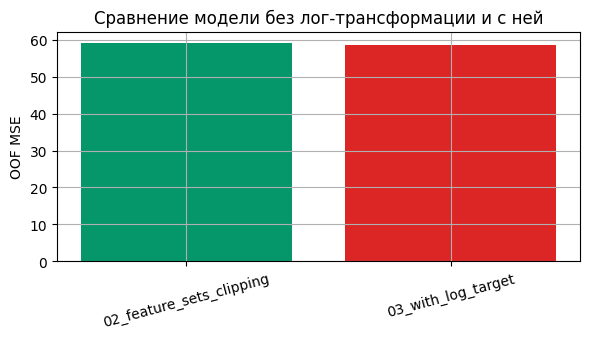

In [17]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(target_transform_comparison["model_step"], target_transform_comparison["oof_mse"], color=["#059669", "#dc2626"])
ax.set_title("Сравнение модели без лог-трансформации и с ней")
ax.set_ylabel("OOF MSE")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


### Вывод по лог-трансформации

Лог-трансформация целевой переменной дала небольшое, но устойчивое улучшение OOF MSE. Этот вариант выбран как финальная линейная модель.


## 10. Вывод


In [18]:
final_comparison = pd.DataFrame([basic_result, v1_result, plain_result, log_result])
display(final_comparison.round(4))

,model_step,n_features,train_mse,train_rmse,oof_mse,oof_rmse
0,00_basic_raw_features,6,77.8058,8.8208,79.9036,8.9389
1,01_added_features,9,59.7710,7.7312,63.2545,7.9533
2,02_feature_sets_clipping,11,55.9258,7.4784,59.3076,7.7011
3,03_with_log_target,11,56.1059,7.4904,58.7477,7.6647


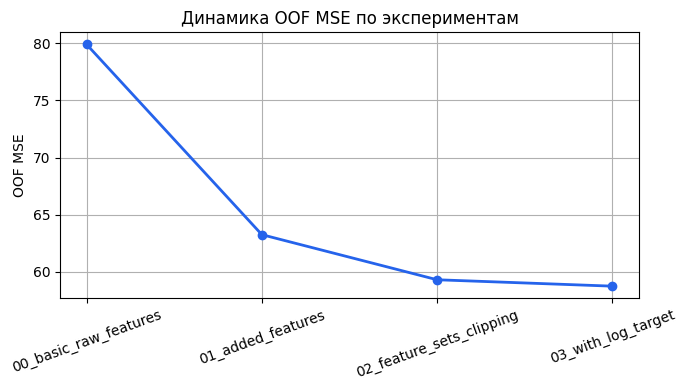

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(final_comparison["model_step"], final_comparison["oof_mse"], marker="o", linewidth=2, color="#2563eb")
ax.set_title("Динамика OOF MSE по экспериментам")
ax.set_ylabel("OOF MSE")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## Промежуточный анализ финальной модели

Для финальной конфигурации используется OOF-прогноз: каждая строка предсказывается моделью, которая не обучалась на этой строке. Это позволяет оценить ошибки без оптимистичного смещения train-метрики.


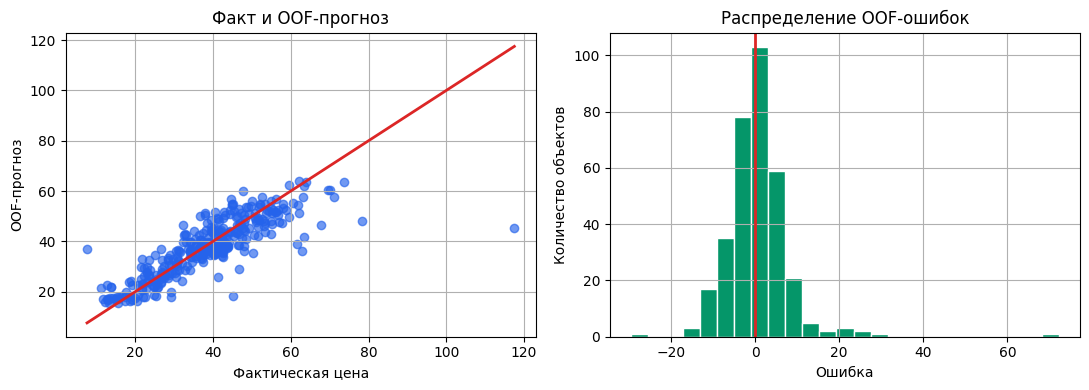

count    331.0000
mean       0.6261
std        7.6507
min      -29.4485
25%       -3.5851
50%        0.4306
75%        3.7309
max       72.2080
Name: Y house price of unit area, dtype: float64

In [20]:
final_oof_pred = cross_val_predict(
    make_log_linear_model(),
    X_train_log[best_features],
    y_train,
    cv=5,
    n_jobs=1,
)
final_residuals = y_train - final_oof_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_train, final_oof_pred, alpha=0.65, color="#2563eb")
lims = [min(y_train.min(), final_oof_pred.min()), max(y_train.max(), final_oof_pred.max())]
axes[0].plot(lims, lims, color="#dc2626", linewidth=2)
axes[0].set_title("Факт и OOF-прогноз")
axes[0].set_xlabel("Фактическая цена")
axes[0].set_ylabel("OOF-прогноз")

axes[1].hist(final_residuals, bins=25, color="#059669", edgecolor="white")
axes[1].axvline(0, color="#dc2626", linewidth=2)
axes[1].set_title("Распределение OOF-ошибок")
axes[1].set_xlabel("Ошибка")
axes[1].set_ylabel("Количество объектов")

plt.tight_layout()
plt.show()

pd.Series(final_residuals).describe().round(4)



Большинство OOF-ошибок сосредоточено около нуля, поэтому модель не имеет выраженного систематического смещения. Наибольшие отклонения остаются для дорогих объектов, что типично для линейной модели с ограниченным набором признаков.


Регуляризация на исходных признаках дала минимальное улучшение: лучший `Ridge` снизил OOF MSE с `79.9036` до `79.8910`.
Поэтапное добавление признаков снизило out-of-fold MSE до `59.3076` после подбора набора признаков и clipping.
Лог-трансформация целевой переменной дополнительно улучшила результат до `58.7477`. Лучшей выбрана конфигурация `compact` с clipping `(0.030, 0.970)` и 11 признаками.
